# Biểu đồ 5 chỉ số — bố cục 3 + 2

Notebook sinh 3 hình cho slide/báo cáo:

| Hình | Nội dung |
|---|---|
| `fig_mimic_5metrics` | MIMIC — 5 panel × (3 tỷ lệ quên × 6 phương pháp) |
| `fig_iu_5metrics` | IU CXR — 5 panel × (6 phương pháp, chỉ 3%) |
| `fig_resource` | 2 chỉ số hiệu quả tài nguyên |

Bố cục 5 panel = **3 trên (khả năng quên / riêng tư: Df-AUC ↓, Df-F1 ↓, MIA ↓) + 2 dưới canh giữa
(khả năng duy trì: Dt-AUC ↑, Dt-F1 ↑)**, dùng **chung 1 legend**, **chung thang Y 0–1**, và màu của
mỗi phương pháp **giữ nguyên qua cả 5 panel**.

**Cách dùng:** chạy Cell 2 → nếu chưa có `experiments/chart_data.csv`, notebook tự tạo template
(đã điền sẵn số MIMIC 3% lấy từ `BANG_5_CHI_SO.md`, phần còn lại để trống). Điền số vào CSV rồi chạy lại.

In [7]:
# =============================================================================
# CELL 1 — Cấu hình
# =============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- knobs -------------------------------------------------------------------
THEME             = "light"      # "light" | "dark"
SHARED_YLIM       = (0.0, 1.0)   # None = mỗi panel tự co giãn (KHÔNG khuyến khích)
SHOW_VALUES_MIMIC = False        # 18 cột/panel -> nhãn số chật; bật nếu in khổ lớn
SHOW_VALUES_IU    = True         # 6 cột/panel -> nhãn số đọc tốt
OUTDIR            = "figures"
DPI               = 300
DATA_CSV          = os.path.join("experiments", "chart_data.csv")

# --- thứ tự phương pháp (thứ tự cột trong mỗi nhóm) --------------------------
METHODS = [
    "OG",         # theta_og  — mo hinh goc
    "GOLD",       # theta_re  — huan luyen lai (chuan vang)
    "NegGrad+",
    "CF-k",
    "Forget-MI",
    "Ours",       # phuong phap de xuat
]
METHOD_LABELS = {
    "OG":        "θ$_{og}$",
    "GOLD":      "θ$_{re}$ (gold)",
    "NegGrad+":  "NegGrad+",
    "CF-k":      "CF-k",
    "Forget-MI": "Forget-MI",
    "Ours":      "Đề xuất",
}

FORGET_PCTS = ["3%", "6%", "10%"]      # trục X của hình MIMIC

# --- panel spec: (tên cột trong CSV, tiêu đề panel) --------------------------
ROW_FORGET = [("Df_AUC", "Df-AUC \u2193"), ("Df_F1", "Df-F1 \u2193"), ("MIA", "MIA \u2193")]
ROW_RETAIN = [("Dt_AUC", "Dt-AUC \u2191"), ("Dt_F1", "Dt-F1 \u2191")]
ROW_TITLES = ("Kh\u1ea3 n\u0103ng qu\u00ean / ri\u00eang t\u01b0", "Kh\u1ea3 n\u0103ng duy tr\u00ec")
METRIC_COLS = [m for m, _ in ROW_FORGET + ROW_RETAIN]

# --- palette (đã validate: adjacent CVD dE 9.1, normal-vision dE 19.6) -------
PALETTE = {
    "light": ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300"],
    "dark":  ["#3987e5", "#d95926", "#199e70", "#c98500", "#d55181", "#008300"],
}
INK = {
    "light": dict(surface="#fcfcfb", primary="#0b0b0b", secondary="#52514e", grid="#e3e2de"),
    "dark":  dict(surface="#1a1a19", primary="#ffffff", secondary="#c3c2b7", grid="#3a3a37"),
}
COLORS = {m: PALETTE[THEME][i] for i, m in enumerate(METHODS)}
C = INK[THEME]

mpl.rcParams.update({
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"],
    "savefig.facecolor": C["surface"],
    "text.color": C["primary"], "axes.labelcolor": C["secondary"],
    "xtick.color": C["secondary"], "ytick.color": C["secondary"],
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "font.family": "DejaVu Sans",   # có sẵn mũi tên up/down
})
os.makedirs(OUTDIR, exist_ok=True)
print("Theme:", THEME, "| so phuong phap:", len(METHODS))

Theme: light | so phuong phap: 6


## Cell 2 — Dữ liệu

Định dạng **long**: mỗi dòng = 1 bộ (dataset, forget_pct, method). Cột:

`dataset, forget_pct, method, Df_AUC, Df_F1, Dt_AUC, Dt_F1, MIA, unlearn_time_hours, gpu_peak_GB`

Ô nào chưa có số thì để trống — notebook bỏ qua cột bar đó (vẽ dấu `–`) và in danh sách còn thiếu.

In [8]:
# =============================================================================
# CELL 2 — Nạp dữ liệu (tự tạo template nếu chưa có)
# =============================================================================
RES_COLS = ["t_fisher_s", "t_train_s", "trainable_params"]
EXTRA_COLS = ["CE_f"]
ALL_COLS = ["dataset", "forget_pct", "method"] + METRIC_COLS + EXTRA_COLS + RES_COLS

# -----------------------------------------------------------------------------
# Số liệu chốt: KLTN_NHNHU_clone_3/Chapter4/chapter4.tex
#   Bảng tab:mimic3 / tab:mimic6 / tab:mimic10 / tab:main-iu  (đo sau 30 epoch)
#   Chi phí: Mục "Chi phí tài nguyên" (fig:cost) — T_core = Fisher + Train
# -----------------------------------------------------------------------------
def _row(df_auc, df_f1, dt_auc, dt_f1, mia, ce):
    return dict(Df_AUC=df_auc, Df_F1=df_f1, Dt_AUC=dt_auc, Dt_F1=dt_f1, MIA=mia, CE_f=ce)

SEED = {
    # ---- MIMIC-CXR 3% (Bảng 4.3) --------------------------------------------
    ("MIMIC", "3%", "OG"):        _row(0.731, 0.419, 0.695, 0.384, 0.657, 1.97),
    ("MIMIC", "3%", "GOLD"):      _row(0.498, 0.179, 0.615, 0.297, 0.423, 4.74),
    ("MIMIC", "3%", "NegGrad+"):  _row(0.162, 0.000, 0.615, 0.316, 0.000, 129.45),
    ("MIMIC", "3%", "CF-k"):      _row(0.912, 0.701, 0.669, 0.380, 0.637, 1.49),
    ("MIMIC", "3%", "Forget-MI"): _row(0.623, 0.278, 0.648, 0.307, 0.627, 3.58),
    ("MIMIC", "3%", "Ours"):      _row(0.683, 0.365, 0.704, 0.394, 0.552, 2.07),
    # ---- MIMIC-CXR 6% (Bảng 4.4) --------------------------------------------
    ("MIMIC", "6%", "OG"):        _row(0.730, 0.434, 0.695, 0.384, 0.736, 1.76),
    ("MIMIC", "6%", "GOLD"):      _row(0.596, 0.339, 0.665, 0.381, 0.613, 2.45),
    ("MIMIC", "6%", "NegGrad+"):  _row(0.102, 0.000, 0.592, 0.318, 0.000, 114.59),
    ("MIMIC", "6%", "CF-k"):      _row(0.927, 0.771, 0.676, 0.403, 0.663, 1.13),
    ("MIMIC", "6%", "Forget-MI"): _row(0.633, 0.296, 0.641, 0.296, 0.773, 3.14),
    ("MIMIC", "6%", "Ours"):      _row(0.670, 0.353, 0.689, 0.370, 0.706, 2.09),
    # ---- MIMIC-CXR 10% (Bảng 4.5) -------------------------------------------
    ("MIMIC", "10%", "OG"):        _row(0.757, 0.469, 0.695, 0.384, 0.717, 1.66),
    ("MIMIC", "10%", "GOLD"):      _row(0.547, 0.274, 0.607, 0.338, 0.364, 3.26),
    ("MIMIC", "10%", "NegGrad+"):  _row(0.207, 0.000, 0.570, 0.278, 0.000, 99.53),
    ("MIMIC", "10%", "CF-k"):      _row(0.925, 0.775, 0.667, 0.383, 0.706, 1.18),
    ("MIMIC", "10%", "Forget-MI"): _row(0.704, 0.349, 0.653, 0.308, 0.616, 2.55),
    ("MIMIC", "10%", "Ours"):      _row(0.728, 0.417, 0.692, 0.384, 0.731, 1.68),
    # ---- IU 3% (Bảng 4.7) — báo cáo KHÔNG chạy NegGrad+/CF-k trên IU --------
    ("IU", "3%", "OG"):        _row(1.000, 1.000, 0.676, 0.622, 0.990, 0.00),
    ("IU", "3%", "GOLD"):      _row(0.651, 0.587, 0.670, 0.614, 0.545, 2.33),
    ("IU", "3%", "Forget-MI"): _row(0.854, 0.616, 0.635, 0.533, 0.581, 3.02),
    ("IU", "3%", "Ours"):      _row(0.710, 0.334, 0.590, 0.351, 0.560, 37.77),
}

# Chi phí (fig:cost). Forget-MI: 1 khối train, không có bước Fisher.
COST = {
    ("MIMIC", "3%",  "Forget-MI"): dict(t_fisher_s=0.0,   t_train_s=2172.5, trainable_params=113238164),
    ("MIMIC", "6%",  "Forget-MI"): dict(t_fisher_s=0.0,   t_train_s=3995.5, trainable_params=113238164),
    ("MIMIC", "10%", "Forget-MI"): dict(t_fisher_s=0.0,   t_train_s=6403.3, trainable_params=113238164),
    ("IU",    "3%",  "Forget-MI"): dict(t_fisher_s=0.0,   t_train_s=1882.6, trainable_params=113238164),
    ("MIMIC", "3%",  "Ours"):      dict(t_fisher_s=270.9, t_train_s=1592.7, trainable_params=1451008),
    ("MIMIC", "6%",  "Ours"):      dict(t_fisher_s=286.9, t_train_s=3102.4, trainable_params=1451008),
    ("MIMIC", "10%", "Ours"):      dict(t_fisher_s=294.2, t_train_s=5447.5, trainable_params=1451008),
    ("IU",    "3%",  "Ours"):      dict(t_fisher_s=259.3, t_train_s=1273.5, trainable_params=1451008),
}

def make_template(path):
    rows = []
    grid = [("MIMIC", p) for p in FORGET_PCTS] + [("IU", "3%")]
    for ds, pct in grid:
        for m in METHODS:
            r = {"dataset": ds, "forget_pct": pct, "method": m}
            r.update({c: np.nan for c in METRIC_COLS + EXTRA_COLS + RES_COLS})
            r.update(SEED.get((ds, pct, m), {}))
            r.update(COST.get((ds, pct, m), {}))
            rows.append(r)
    df = pd.DataFrame(rows)[ALL_COLS]
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    df.to_csv(path, index=False)
    return df

if os.path.exists(DATA_CSV):
    data = pd.read_csv(DATA_CSV)
    print("Da nap:", DATA_CSV)
else:
    data = make_template(DATA_CSV)
    print("Chua co du lieu -> da tao template:", DATA_CSV)
    print("   => Mo file, dien so, roi chay lai cell nay.")

for c in ALL_COLS:
    if c not in data.columns:
        data[c] = np.nan
for c in METRIC_COLS + EXTRA_COLS + RES_COLS:
    data[c] = pd.to_numeric(data[c], errors="coerce")

missing = []
for r in data.itertuples():
    gaps = [c for c in METRIC_COLS if pd.isna(getattr(r, c))]
    if gaps:
        missing.append("{} {} {}: {}".format(r.dataset, r.forget_pct, r.method, ", ".join(gaps)))
if missing:
    print("\nCon thieu {} dong (o trong se khong ve cot bar):".format(len(missing)))
    for s in missing[:24]:
        print("  -", s)

# Table view — đi kèm hình (một vài màu < 3:1 tương phản nền nên cần bảng số).
display(data.set_index(["dataset", "forget_pct", "method"])[METRIC_COLS + EXTRA_COLS].round(3))

Da nap: experiments\chart_data.csv

Con thieu 2 dong (o trong se khong ve cot bar):
  - IU 3% NegGrad+: Df_AUC, Df_F1, MIA, Dt_AUC, Dt_F1
  - IU 3% CF-k: Df_AUC, Df_F1, MIA, Dt_AUC, Dt_F1


Df_AUC  Df_F1    MIA  Dt_AUC  Dt_F1    CE_f
dataset forget_pct method                                                
MIMIC   3%         OG          0.731  0.419  0.657   0.695  0.384    1.97
                   GOLD        0.498  0.179  0.423   0.615  0.297    4.74
                   NegGrad+    0.162  0.000  0.000   0.615  0.316  129.45
                   CF-k        0.912  0.701  0.637   0.669  0.380    1.49
                   Forget-MI   0.623  0.278  0.627   0.648  0.307    3.58
                   Ours        0.683  0.365  0.552   0.704  0.394    2.07
        6%         OG          0.730  0.434  0.736   0.695  0.384    1.76
                   GOLD        0.596  0.339  0.613   0.665  0.381    2.45
                   NegGrad+    0.102  0.000  0.000   0.592  0.318  114.59
                   CF-k        0.927  0.771  0.663   0.676  0.403    1.13
                   Forget-MI   0.633  0.296  0.773   0.641  0.296    3.14
                   Ours        0.670  0.353  0.706   0.689  0.370    2.09
        10%        OG          0.757  0.469  0.717   0.695  0.384    1.66
                   GOLD        0.547  0.274  0.364   0.607  0.338    3.26
                   NegGrad+    0.207  0.000  0.000   0.570  0.278   99.53
                   CF-k        0.925  0.775  0.706   0.667  0.383    1.18
                   Forget-MI   0.704  0.349  0.616   0.653  0.308    2.55
                   Ours        0.728  0.417  0.731   0.692  0.384    1.68
IU      3%         OG          1.000  1.000  0.990   0.676  0.622    0.00
                   GOLD        0.651  0.587  0.545   0.670  0.614    2.33
                   NegGrad+      NaN    NaN    NaN     NaN    NaN     NaN
                   CF-k          NaN    NaN    NaN     NaN    NaN     NaN
                   Forget-MI   0.854  0.616  0.581   0.635  0.533    3.02
                   Ours        0.710  0.334  0.560   0.590  0.351   37.77

In [9]:
# =============================================================================
# CELL 3 — Hàm vẽ: lưới 3 + 2, dùng chung 1 legend
# =============================================================================
BAR_GAP   = 0.02    # khe hở giữa 2 cột kề nhau
GROUP_PAD = 0.42    # khe hở giữa các nhóm

def _get(df, ds, pct, method, col):
    s = df[(df.dataset == ds) & (df.forget_pct == pct) & (df.method == method)][col]
    return float(s.iloc[0]) if len(s) and pd.notna(s.iloc[0]) else np.nan

def _panel(ax, df, ds, groups, col, title, show_values):
    """Vẽ 1 panel: mỗi group (tỷ lệ quên) gồm len(METHODS) cột."""
    n = len(METHODS)
    pad = GROUP_PAD if len(groups) > 1 else 0.16   # 1 nhóm -> cột to hơn cho dễ đọc
    slot = (1.0 - pad) / n
    w = slot * (1 - BAR_GAP)
    for gi, g in enumerate(groups):
        for mi, m in enumerate(METHODS):
            v = _get(df, ds, g, m, col)
            x = gi + (mi - (n - 1) / 2.0) * slot
            if np.isnan(v):
                ax.text(x, 0.02, "\u2013", ha="center", va="bottom",
                        color=C["secondary"], fontsize=8)
                continue
            if v == 0:            # gia tri that bang 0 -> ghi "0", khong lan voi o thieu
                ax.text(x, 0.015, "0", ha="center", va="bottom",
                        fontsize=7.5, fontweight="bold", color=COLORS[m], zorder=4)
                continue
            ax.bar(x, v, width=w, color=COLORS[m], linewidth=0, zorder=3)
            if show_values:
                hi = SHARED_YLIM[1] if SHARED_YLIM else None
                inside = hi is not None and v > 0.82 * hi   # cot cao -> ghi trong cot
                ax.text(x, v - 0.02 if inside else v + 0.015,
                        ("%.3f" % v).lstrip("0"),
                        ha="center", va="top" if inside else "bottom",
                        rotation=90, fontsize=6.5,
                        color=C["primary"] if inside else C["secondary"], zorder=4)

    ax.set_title(title, color=C["primary"], pad=8)
    ax.set_xticks(range(len(groups)))
    ax.set_xticklabels(groups)
    ax.set_xlim(-0.5, len(groups) - 0.5)
    if SHARED_YLIM:
        ax.set_ylim(*SHARED_YLIM)
        ax.set_yticks(np.arange(SHARED_YLIM[0], SHARED_YLIM[1] + 1e-9, 0.2))
    ax.yaxis.grid(True, color=C["grid"], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(C["grid"])
    ax.tick_params(length=0)

def plot_5panels(df, ds, groups, suptitle, show_values, figsize=(15, 8.2), xlabel=None):
    """3 panel hàng trên + 2 panel hàng dưới canh giữa + 1 legend chung."""
    fig = plt.figure(figsize=figsize)
    gs = fig.add_gridspec(2, 12, hspace=0.45, wspace=0.9,
                          left=0.06, right=0.98, top=0.83, bottom=0.15)
    axes_top = [fig.add_subplot(gs[0, i:i + 4]) for i in (0, 4, 8)]
    axes_bot = [fig.add_subplot(gs[1, i:i + 4]) for i in (2, 6)]

    for ax, (col, title) in zip(axes_top, ROW_FORGET):
        _panel(ax, df, ds, groups, col, title, show_values)
    for ax, (col, title) in zip(axes_bot, ROW_RETAIN):
        _panel(ax, df, ds, groups, col, title, show_values)

    if xlabel:
        for ax in axes_top + axes_bot:
            ax.set_xlabel(xlabel, fontsize=9)

    # nhãn ngữ nghĩa cho từng hàng
    fig.text(0.015, 0.865, ROW_TITLES[0], fontsize=10.5, fontweight="bold",
             color=C["secondary"], ha="left")
    fig.text(0.015, 0.445, ROW_TITLES[1], fontsize=10.5, fontweight="bold",
             color=C["secondary"], ha="left")
    fig.suptitle(suptitle, fontsize=14, fontweight="bold", color=C["primary"], y=0.965)

    handles = [Patch(facecolor=COLORS[m], label=METHOD_LABELS.get(m, m)) for m in METHODS]
    fig.legend(handles=handles, loc="lower center", ncol=len(METHODS),
               frameon=False, bbox_to_anchor=(0.5, 0.01), fontsize=10,
               labelcolor=C["secondary"], handlelength=1.2, columnspacing=1.6)
    return fig, axes_top + axes_bot

def save(fig, name):
    for ext in ("png", "pdf"):
        p = os.path.join(OUTDIR, name + "." + ext)
        fig.savefig(p, dpi=DPI, bbox_inches="tight", facecolor=fig.get_facecolor())
        print("saved:", p)

saved: figures\fig_mimic_5metrics.png
saved: figures\fig_mimic_5metrics.pdf


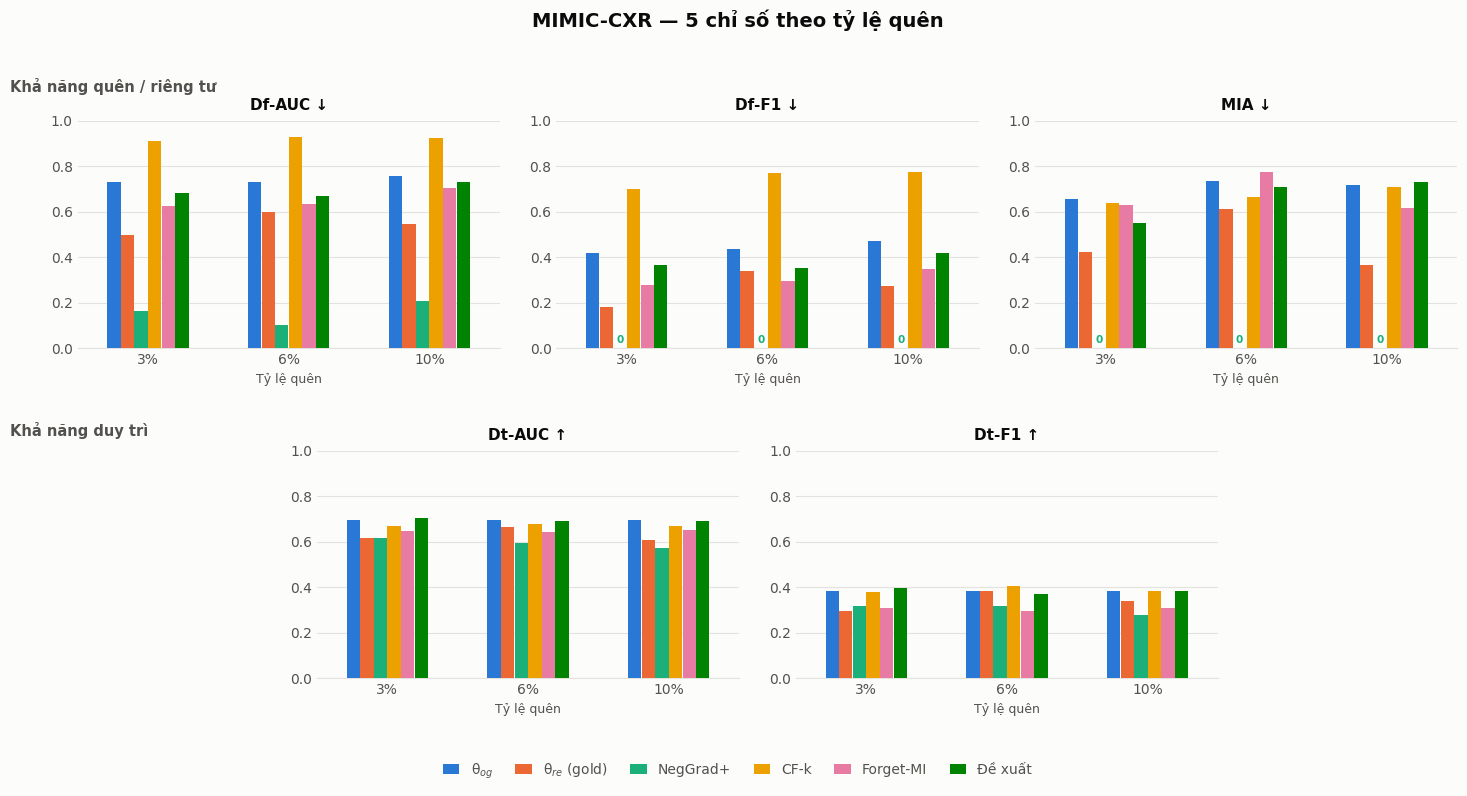

In [10]:
# =============================================================================
# CELL 4 — MIMIC: 5 chỉ số × 3 tỷ lệ quên
# =============================================================================
fig, _ = plot_5panels(
    data, ds="MIMIC", groups=FORGET_PCTS,
    suptitle="MIMIC-CXR \u2014 5 ch\u1ec9 s\u1ed1 theo t\u1ef7 l\u1ec7 qu\u00ean",
    show_values=SHOW_VALUES_MIMIC,
    figsize=(15, 8.2), xlabel="T\u1ef7 l\u1ec7 qu\u00ean",
)
save(fig, "fig_mimic_5metrics")
plt.show()

saved: figures\fig_iu_5metrics.png
saved: figures\fig_iu_5metrics.pdf


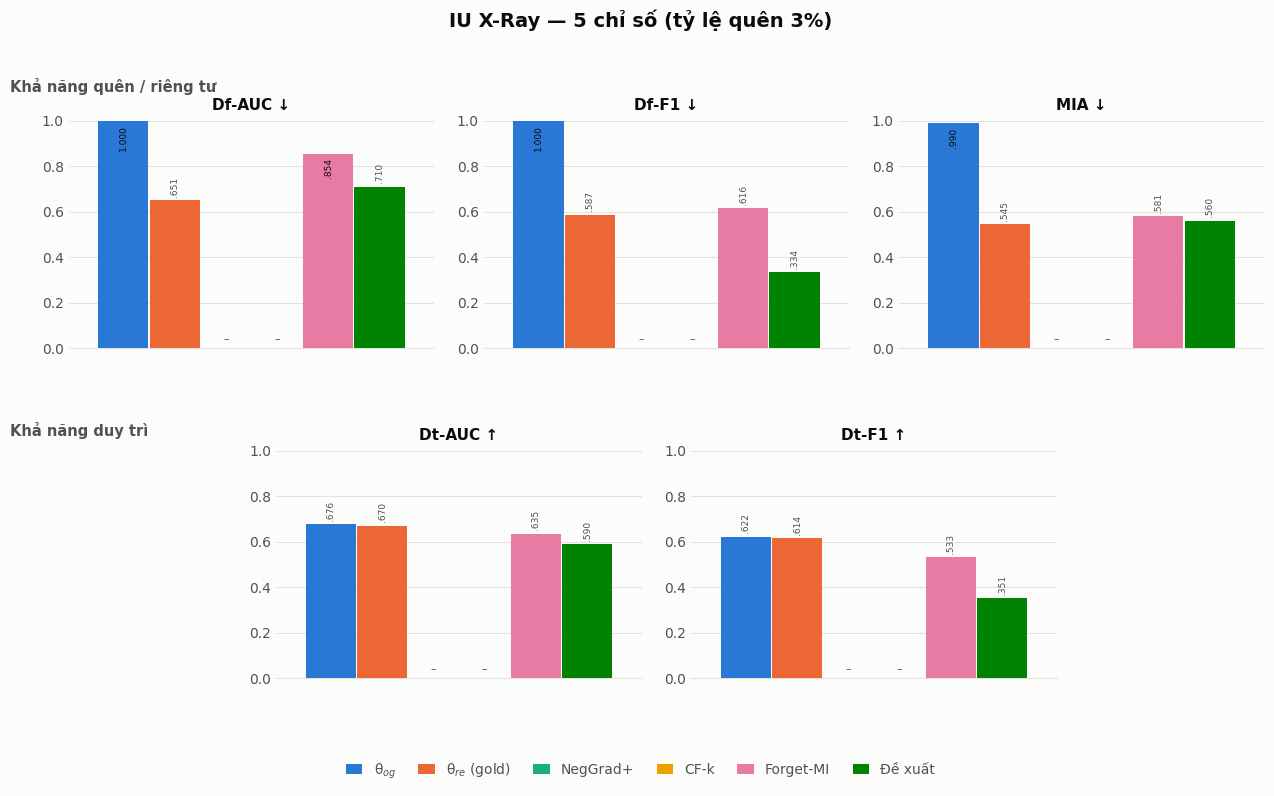

In [11]:
# =============================================================================
# CELL 5 — IU CXR: 5 chỉ số, chỉ tỷ lệ 3% (mỗi panel 6 cột)
# =============================================================================
fig, axes = plot_5panels(
    data, ds="IU", groups=["3%"],
    suptitle="IU X-Ray \u2014 5 ch\u1ec9 s\u1ed1 (t\u1ef7 l\u1ec7 qu\u00ean 3%)",
    show_values=SHOW_VALUES_IU,
    figsize=(13, 8.2), xlabel=None,
)
for ax in axes:          # 1 nhóm duy nhất -> nhãn "3%" trên trục X là thừa
    ax.set_xticks([])
save(fig, "fig_iu_5metrics")
plt.show()

saved: figures\fig_resource.png
saved: figures\fig_resource.pdf


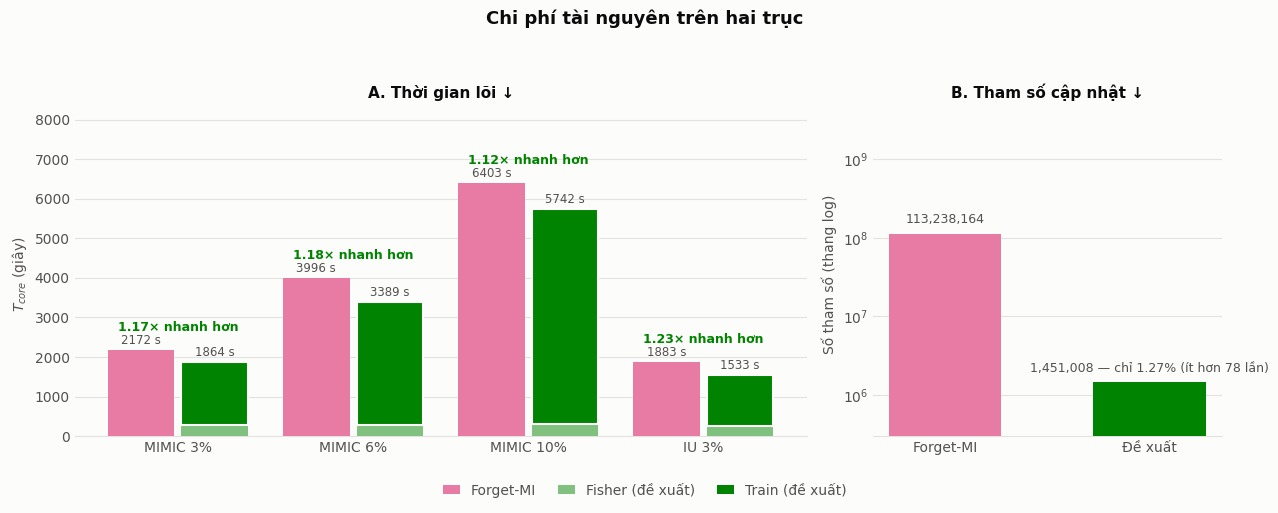

t_fisher_s  t_train_s  trainable_params
dataset forget_pct method                                            
MIMIC   3%         Forget-MI         0.0     2172.5       113238164.0
                   Ours            270.9     1592.7         1451008.0
        6%         Forget-MI         0.0     3995.5       113238164.0
                   Ours            286.9     3102.4         1451008.0
        10%        Forget-MI         0.0     6403.3       113238164.0
                   Ours            294.2     5447.5         1451008.0
IU      3%         Forget-MI         0.0     1882.6       113238164.0
                   Ours            259.3     1273.5         1451008.0

In [12]:
# =============================================================================
# CELL 6 — Chi phí tài nguyên (khớp fig:cost trong Chương 4)
#   Panel A: T_core = Fisher + Train (giây) — Forget-MI vs Đề xuất
#   Panel B: số tham số cập nhật (thang log)
# =============================================================================
COST_SETTINGS = [("MIMIC", "3%"), ("MIMIC", "6%"), ("MIMIC", "10%"), ("IU", "3%")]
C_FMI, C_OURS = COLORS["Forget-MI"], COLORS["Ours"]
C_FISHER = "#80c180"   # tint nhạt của màu "Đề xuất", tách phần Fisher

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5), gridspec_kw={"width_ratios": [2.1, 1]})

# ---- Panel A ---------------------------------------------------------------
labels, sp = [], 0.21
for i, (ds, pct) in enumerate(COST_SETTINGS):
    labels.append("%s %s" % (ds, pct))
    t_fmi = _get(data, ds, pct, "Forget-MI", "t_train_s") +             np.nan_to_num(_get(data, ds, pct, "Forget-MI", "t_fisher_s"))
    fish  = _get(data, ds, pct, "Ours", "t_fisher_s")
    train = _get(data, ds, pct, "Ours", "t_train_s")
    axA.bar(i - sp, t_fmi, width=0.38, color=C_FMI, linewidth=0, zorder=3)
    axA.bar(i + sp, fish,  width=0.38, color=C_FISHER, linewidth=0, zorder=3)
    axA.bar(i + sp, train, width=0.38, bottom=fish, color=C_OURS, zorder=3,
            edgecolor=C["surface"], linewidth=1.5)          # khe 2px giữa 2 phần
    tot = fish + train
    axA.text(i - sp, t_fmi + 80, "%d s" % round(t_fmi), ha="center", va="bottom",
             fontsize=8.5, color=C["secondary"], zorder=4)
    axA.text(i + sp, tot + 80, "%d s" % round(tot), ha="center", va="bottom",
             fontsize=8.5, color=C["secondary"], zorder=4)
    axA.text(i, max(t_fmi, tot) + 400, "%.2f× nhanh hơn" % (t_fmi / tot),
             ha="center", va="bottom", fontsize=9, fontweight="bold",
             color=C_OURS, zorder=4)

axA.set_xticks(range(len(labels))); axA.set_xticklabels(labels)
axA.set_ylabel("$T_{core}$ (giây)", fontsize=10)
axA.set_title("A. Thời gian lõi ↓", color=C["primary"], pad=10)
axA.set_ylim(0, 8200)
axA.yaxis.grid(True, color=C["grid"], linewidth=0.8, zorder=0); axA.set_axisbelow(True)
for k in ("top", "right", "left"): axA.spines[k].set_visible(False)
axA.spines["bottom"].set_color(C["grid"]); axA.tick_params(length=0)

# ---- Panel B ---------------------------------------------------------------
prm = [(_get(data, "MIMIC", "3%", m, "trainable_params"), m) for m in ("Forget-MI", "Ours")]
for i, (v, m) in enumerate(prm):
    axB.bar(i, v, width=0.55, color=COLORS[m], linewidth=0, zorder=3)
    note = "" if m == "Forget-MI" else " — chỉ 1.27% (ít hơn 78 lần)"
    axB.text(i, v * 1.25, "{:,}".format(int(v)) + note, ha="center", va="bottom",
             fontsize=9, color=C["secondary"], zorder=4)
axB.set_yscale("log"); axB.set_ylim(3e5, 4e9)
axB.minorticks_off()
axB.set_xticks([0, 1]); axB.set_xticklabels(["Forget-MI", "Đề xuất"])
axB.set_ylabel("Số tham số (thang log)", fontsize=10)
axB.set_title("B. Tham số cập nhật ↓", color=C["primary"], pad=10)
axB.yaxis.grid(True, color=C["grid"], linewidth=0.8, zorder=0); axB.set_axisbelow(True)
for k in ("top", "right", "left"): axB.spines[k].set_visible(False)
axB.spines["bottom"].set_color(C["grid"]); axB.tick_params(length=0)

handles = [Patch(facecolor=C_FMI, label="Forget-MI"),
           Patch(facecolor=C_FISHER, label="Fisher (đề xuất)"),
           Patch(facecolor=C_OURS, label="Train (đề xuất)")]
fig.legend(handles=handles, loc="lower center", ncol=3, frameon=False,
           bbox_to_anchor=(0.5, -0.02), fontsize=10, labelcolor=C["secondary"],
           handlelength=1.2, columnspacing=1.6)
fig.suptitle("Chi phí tài nguyên trên hai trục", fontsize=13,
             fontweight="bold", color=C["primary"])
fig.tight_layout(rect=[0, 0.06, 1, 0.93])
save(fig, "fig_resource")
plt.show()

# FILA < 1 giây ở mọi thiết lập nên không vẽ theo tỷ lệ (giống chú thích fig:cost).
display(data[data.method.isin(["Forget-MI", "Ours"])]
        [["dataset", "forget_pct", "method"] + RES_COLS]
        .dropna(subset=["t_train_s"]).set_index(["dataset", "forget_pct", "method"]))